In [15]:
# import general packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors
from scipy.optimize import brentq

colorWM = "#06948E"
colorPS_D = "#5C5D9E"
colorPS_D_light = "#AAABDE"
colorPS_R = "#EF74C0"
colorPS_R_light = "#F9DCA6"

plt.rcParams.update({
    # Font sizes
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,

    # Line widths
    "lines.linewidth": 1,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Tick sizes
    "xtick.major.size": 2,
    "ytick.major.size": 2,

    # Font family
    "font.family": "Arial"
})


In [2]:
def mean_field(t, z, alpha, k, delta):
    """
    Parameters:
        t      : Time (required for ODE solvers)
        z      : List or array of concentrations [x1, x2, ..., xN]
        alpha  : Production rate of x1 (float)
        k      : List of production rate constants from x_{i-1} to x_i, length N-1
        delta  : List of degradation rate constants, length N
    Returns:
        dzdt   : List of time derivatives [dx1/dt, dx2/dt, ..., dxN/dt]
    """
    N = len(z)
    dzdt = [0.0] * N

    # x1 dynamics
    dzdt[0] = alpha - delta[0] * z[0] * z[-1]  # z[-1] is xN

    # x_i dynamics for i = 2 to N
    for i in range(1, N):
        dzdt[i] = k[i-1] * z[i-1] - delta[i] * z[i]

    return dzdt

def mean_field_phasesep(t, z, a1, alpha, k, delta):
    """
    Parameters:
        t      : Time (required for ODE solvers)
        z      : List or array of concentrations [x1, x2, ..., xN]
        a1  : Production rate of x1 (float)
        alpha : exponent of degradation
        k      : List of production rate constants from x_{i-1} to x_i, length N-1
        delta  : List of degradation rate constants, length N
    Returns:
        dzdt   : List of time derivatives [dx1/dt, dx2/dt, ..., dxN/dt]
    """
    N = len(z)
    dzdt = [0.0] * N

    # x1 dynamics
    dzdt[0] = a1 - delta[0] * z[0]**(alpha) * z[-1]  # z[-1] is xN

    # x_i dynamics for i = 2 to N
    for i in range(1, N):
        dzdt[i] = k[i-1] * z[i-1] - delta[i] * z[i]

    return dzdt

def mean_field_xNphasesep(t, z, a1, alpha, k, delta):
    """
    Parameters:
        t      : Time (required for ODE solvers)
        z      : List or array of concentrations [x1, x2, ..., xN]
        a1  : Production rate of x1 (float)
        alpha : exponent of degradation
        k      : List of production rate constants from x_{i-1} to x_i, length N-1
        delta  : List of degradation rate constants, length N
    Returns:
        dzdt   : List of time derivatives [dx1/dt, dx2/dt, ..., dxN/dt]
    """
    N = len(z)
    dzdt = [0.0] * N

    # x1 dynamics
    dzdt[0] = a1 - delta[0] * z[0] * z[-1]**(alpha)  # z[-1] is xN

    # x_i dynamics for i = 2 to N
    for i in range(1, N):
        dzdt[i] = k[i-1] * z[i-1] - delta[i] * z[i]

    return dzdt

def get_cartesian_style_axis(ax):
    # Hide top, right, left spines (borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Hide y-axis and y-ticks
    ax.yaxis.set_visible(True)

    # Only keep the bottom spine (x-axis)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    # Only show x-ticks
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def get_n_colors(n):
    base_colors = ["tab:blue", "tab:orange", "tab:red", "tab:green"]
    if n <= len(base_colors):
        return base_colors[:n]
    else:
        cmap = plt.get_cmap("tab20")  # or 'hsv', 'nipy_spectral' for more variety
        extra_colors = [cmap(i / (n - len(base_colors))) for i in range(n - len(base_colors))]
        # Convert RGBA to hex or keep as RGBA
        extra_colors = [mcolors.to_hex(c) for c in extra_colors]
        return base_colors + extra_colors

# Well-mixed ODE

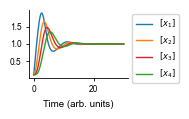

In [16]:
N = 4

alpha = 1
k = np.ones((N-1))         # len = N-1
delta = np.ones((N))   # len = N

z0 = [0.1] * N
tspan = (0, 30)
sol_mean_field = solve_ivp(lambda t, z: mean_field(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

colors = get_n_colors(N)

plt.figure(figsize=(1.9, 1.2))
for i in range(N):
    plt.plot(sol_mean_field.t, sol_mean_field.y[i], color = colors[i], label = r"$[x_"+str(i+1)+"]$")
plt.legend(bbox_to_anchor=(1.0, 1),
                         loc='upper left')
plt.xlabel("Time (arb. units)")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/WM_damped.svg",
            transparent = True,    
            dpi=300,
            bbox_inches="tight")

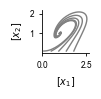

In [17]:
plt.figure(figsize=(1,1))
for x10 in np.linspace(0.1,1.8,5):
        z0[0] = x10
        tspan = (0, 30)
        sol_mean_field = solve_ivp(lambda t, z: mean_field(t, z, alpha, k, delta), tspan, z0, max_step=0.1)

        plt.plot(sol_mean_field.y[0], sol_mean_field.y[1], color = "gray")

ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/wave.svg",
                transparent = True,    
            dpi=300,
            bbox_inches="tight")

# Phase-sep ODE

## N>5

/var/folders/2l/dq7pxpgx0nz8tkgcfl___njw0000gn/T/ipykernel_43961/1938562921.py:40: RuntimeWarning: invalid value encountered in scalar power
  dzdt[0] = a1 - delta[0] * z[0]**(alpha) * z[-1]  # z[-1] is xN


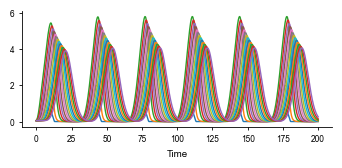

In [18]:
N = 15
a1 = 1/9
alpha = 1/3
k = 1*np.ones((N-1))        
k[0] = k[1] =  3
delta = 1*np.ones((N))

z0 = [0.05] * N
tspan = (0, 200)
sol_mean_field = solve_ivp(lambda t, z: mean_field_phasesep(t, z, a1, alpha, k, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]

plt.figure(figsize=(4,1.5))
for i in range(N):
    plt.plot(sol_mean_field.t, sol_mean_field.y[i])

plt.xlabel("Time")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.show()

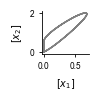

In [19]:
i = 0
plt.figure(figsize=(1,1))
plt.plot(sol_mean_field.y[i][-20000:], sol_mean_field.y[i+1][-20000:], color = "gray")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/limit_cycle_PS.svg", 
            transparent = True,    
            dpi=300,
            bbox_inches="tight"
)

## N<5

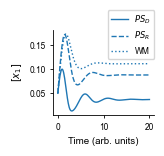

In [20]:
N = 3
a1_D = 1/9
a1_R = (2/3)**5
alpha_D = 1/3
alpha_R = 2/3
k_D = np.ones((N-1))         # len = N-1
k_D[0] = k_D[1] = 3

k_R = np.ones((N-1))         # len = N-1
k_R[0] = 1/a1_R

delta = np.ones((N))   # len = N

z0 = [0.05] * N
tspan = (0, 20)
sol_mean_fieldPS_D = solve_ivp(lambda t, z: mean_field_phasesep(t, z, a1_D, alpha_D, k_D, delta), tspan, z0, max_step=0.1)
sol_mean_fieldPS_R = solve_ivp(lambda t, z: mean_field_phasesep(t, z, a1_R, alpha_R, k_R, delta), tspan, z0, max_step=0.1)
sol_mean_fieldWM = solve_ivp(lambda t, z: mean_field(t, z, a1, k, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]
plt.figure(figsize=(1.3,1.1))
for i in range(1):
    plt.plot(sol_mean_fieldPS_D.t, sol_mean_fieldPS_D.y[i], color = "tab:blue", linestyle = "-", label = r"$PS_D$")#, color = colors[i], label = r"$[x_"+str(i+1)+"]$")
    plt.plot(sol_mean_fieldPS_R.t, sol_mean_fieldPS_R.y[i], color = "tab:blue", linestyle = "--", label = r"$PS_R$")#, color = colors[i], label = r"$[x_"+str(i+1)+"]$")
    plt.plot(sol_mean_fieldWM.t, sol_mean_fieldWM.y[i], color ="tab:blue", linestyle = ":", label = "WM")
ax = plt.gca()
ax.legend(loc="center left", bbox_to_anchor=(0.5, 0.95))

plt.xlabel("Time (arb. units)")
plt.ylabel(r"$[x_1]$")
ax = plt.gca()
get_cartesian_style_axis(ax)

plt.savefig("./neg_feedback_loop_paper_figures/WM_vs_PS.svg",
            transparent = True,    
            dpi=300,
            bbox_inches="tight")

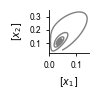

In [23]:
N = 4
a1_D = 1/9
alpha_D = 1/3
k_D = np.ones((N-1))         # len = N-1
k_D[0] = k_D[1] = 3

delta = np.ones((N))   # len = N

z0 = [0.05] * N
tspan = (0,200)
sol_mean_fieldPS_D = solve_ivp(lambda t, z: mean_field_phasesep(t, z, a1_D, alpha_D, k_D, delta), tspan, z0, max_step=0.1)

colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "tab:brown"]
plt.figure(figsize=(1,1))
plt.plot(sol_mean_fieldPS_D.y[0][:], sol_mean_fieldPS_D.y[1][:], color = "gray")
ax = plt.gca()
get_cartesian_style_axis(ax)
plt.xlabel(r"$[x_1]$")
plt.ylabel(r"$[x_2]$")
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/spiral.svg",
            transparent = True,    
            dpi=300,
            bbox_inches="tight"
)

In [22]:
def re_lambda_PS_cont(n, alpha):
    return alpha**(-1/n) * np.cos(np.pi / n) - 1


def find_continuous_root(alpha, n_min=2.01, n_max=20):
    return brentq(re_lambda_PS_cont, n_min, n_max, args=(alpha,))
roots = np.zeros(2)

for i,alpha in enumerate([1/3, 2/3]):
    roots[i] = find_continuous_root(alpha)
    print(f"alpha={alpha}: continuous root at n ≈ {roots[i]:.2f}")

alpha=0.3333333333333333: continuous root at n ≈ 4.85
alpha=0.6666666666666666: continuous root at n ≈ 12.31


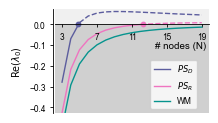

In [11]:
num_states = np.arange(3, 20)

plt.figure(figsize=(2.2,1.25))
alphas = [1/3, 2/3]
Ncrit = [5, 12]
labels = [r"$PS_D$", r"$PS_R$"]
colors = [colorPS_D, colorPS_R]
re_lambda_WM = np.cos(np.pi/num_states) -1
im_lambda_WM = np.sin(np.pi/num_states)


for ind,alpha in enumerate(alphas):
    a_1 = (1/(alpha))**((alpha+1)/(alpha-1))
    real_part_lambda = a_1 ** (-1 / (2 * num_states)) * np.cos(np.pi / num_states) - 1

    re_lambda_PS = alpha**(-1/num_states)*np.cos(np.pi/num_states) -1
    im_lambda_PS = alpha**(-1/num_states)*np.sin(np.pi/num_states)
    ax = plt.gca()

    ax.plot(num_states[num_states<=Ncrit[ind]], re_lambda_PS[num_states<=Ncrit[ind]], color=colors[ind], zorder=1, label = labels[ind])
    ax.plot(num_states[num_states>=Ncrit[ind]], re_lambda_PS[num_states>=Ncrit[ind]], linestyle = "--", color=colors[ind], zorder=1)
    
    # Shade region where y > 0
    ax.axhspan(0, ax.get_ylim()[1], facecolor="#f0f0f0", zorder=0)
    ax.scatter([roots[ind]],[0], color = colors[ind], s=10)
    # Shade region where y < 0
    ax.axhspan(ax.get_ylim()[0], 0, facecolor="#d0d0d0", zorder=0)

# Plot the curve
ax = plt.gca()
ax.plot(num_states, re_lambda_WM, color=colorWM, zorder=100, label = "WM")
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis at y = 0
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 2))
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# Adjust y-limits to show a bit more positive space
ymin, ymax = re_lambda_PS.min(), re_lambda_PS.max()
ax.set_ylim(ymin, ymax + 0.15 * (ymax - ymin))


# Set xticks at all integers 1 through 20
ax.set_xticks(num_states[::4])

# Set xlabel manually at bottom right
ax.text(num_states[-1] + 0.5, -0.08, "# nodes (N)", ha='right', va='top')

# Y-axis label
ax.set_ylabel(r"$\mathrm{Re}(\lambda_0)$")
plt.legend(bbox_to_anchor=(0.95, 0),
                         loc='lower right')
plt.tight_layout()

plt.savefig("./neg_feedback_loop_paper_figures/re_lambda.svg",
            transparent = True,    
            dpi=300,
            bbox_inches="tight"
)

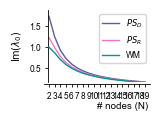

In [12]:
num_states = np.arange(2, 20)

plt.figure(figsize=(1.6, 1.3))
alphas = [1/3, 2/3]
labels = [r"$PS_D$", r"$PS_R$"]
colors = [colorPS_D, colorPS_R]
re_lambda_WM = np.cos(np.pi/num_states) -1
im_lambda_WM = np.sin(np.pi/num_states)


for ind,alpha in enumerate(alphas):
    ax = plt.gca()
    a_1 = (1/(alpha))**((alpha+1)/(alpha-1))
    real_part_lambda = a_1 ** (-1 / (2 * num_states)) * np.cos(np.pi / num_states) - 1

    re_lambda_PS = a_1**((1/num_states)*(alpha-1)/(alpha+1))*np.cos(np.pi/num_states) -1
    im_lambda_PS = a_1**((1/num_states)*(alpha-1)/(alpha+1))*np.sin(np.pi/num_states)
    if ind == 0:
        # Adjust y-limits to show a bit more positive space
        ymin, ymax = im_lambda_PS.min(), im_lambda_PS.max()
    ax.plot(num_states, im_lambda_PS, color=colors[ind], zorder=1, label = labels[ind])

# Plot the curve
ax = plt.gca()
ax.plot(num_states, im_lambda_WM, color=colorWM, zorder=100, label = "WM")
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis at y = 0
ax.spines['bottom'].set_position(('data', ymin-0.05))
ax.spines['left'].set_position(('data', 2-0.1))
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


ax.set_ylim(ymin, ymax + 0.1 * (ymax - ymin))

# Set xticks at all integers 1 through 10
ax.set_xticks(num_states[:])

# Set xlabel manually at bottom right
ax.text(num_states[-1] + 0.5, -0.3, "# nodes (N)", ha='right', va='top')

# Y-axis label
ax.set_ylabel(r"$\mathrm{Im}(\lambda_0)$")
plt.legend()
plt.tight_layout()
plt.savefig("./neg_feedback_loop_paper_figures/im_lambda.svg",            
            transparent = True,    
            dpi=300,
            bbox_inches="tight"
)